# BANK LOAN ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [2]:
df = pd.read_csv("D:/Downloads/Finance Loan Dashboard/financial_loan.csv")

In [3]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [4]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,11-07-2021,16-05-2021,16-05-2021,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,11-10-2021,16-04-2021,16-05-2021,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,11-09-2021,16-05-2021,16-05-2021,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,11-10-2021,16-05-2021,16-05-2021,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,11-07-2021,16-05-2021,16-05-2021,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


### Metadata of Data

In [5]:
print("No of rows: ",df.shape[0])
print("No of fields: ",df.shape[1])

No of rows:  38576
No of fields:  24


In [6]:
df.info

<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership  issue_date  \
0                                Ryder     C           RENT  11-02-2021   
1                       MKC Accounting     E           RENT  01-01-2021   
2                Chema

In [7]:
df.dtypes

id                         int64
address_state             object
application_type          object
emp_length                object
emp_title                 object
grade                     object
home_ownership            object
issue_date                object
last_credit_pull_date     object
last_payment_date         object
loan_status               object
next_payment_date         object
member_id                  int64
purpose                   object
sub_grade                 object
term                      object
verification_status       object
annual_income            float64
dti                      float64
installment              float64
int_rate                 float64
loan_amount                int64
total_acc                  int64
total_payment              int64
dtype: object

In [8]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


# KPI's

### Total Loan Application

In [9]:
Total_Loan_Application = df['id'].count()
print("Total Loan Application:",Total_Loan_Application)

Total Loan Application: 38576


### MTD Total Loan Applications

In [10]:
df['issue_date'] = pd.to_datetime(df['issue_date'], dayfirst=True)

latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_loan_applications = mtd_data['id'].count()

print(f"MTD Loan Applications(for {latest_issue_date.strftime('%B %Y')}):{mtd_loan_applications}")

MTD Loan Applications(for December 2021):4314


### Total Funded Amount

In [11]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $435.76M


### MTD Total Funded Amount

In [12]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_date = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount = mtd_date['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount/1000000

print("MTD Total Funded Amount: ${:.2f}M".format(mtd_total_funded_amount_millions))

MTD Total Funded Amount: $53.98M


### Total Amount Received

In [13]:
Total_Amount_Received = df['total_payment'].sum()
Total_Amount_Received_millions = Total_Amount_Received/1000000
print("Total Amount Received: ${:.2f}M".format(Total_Amount_Received_millions))

Total Amount Received: $473.07M


### MTD Total Amount Received

In [14]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_date = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received = mtd_date['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_amount_received/1000000

print("MTD Total Amount received: ${:.2f}M".format(mtd_total_amount_received_millions))

MTD Total Amount received: $58.07M


### Average Interest Rate

In [15]:
Average_Interest_Rate = df['int_rate'].mean()*100
print("Average Interest Rate:{:.2f}%".format(Average_Interest_Rate))

Average Interest Rate:12.05%


### Average Debt to income ratio(DTI)

In [16]:
avg_dti = df['dti'].mean()*100
print("Avg DTI:{:.2f}%".format(avg_dti))

Avg DTI:13.33%


### Good Loan Metrics

In [17]:
good_loans = df[df['loan_status'].isin(["Fully Paid","Current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount/1000000
good_loan_received_millions = good_loan_received/1000000

good_loan_percentage = (good_loan_applications/total_loan_applications)* 100

print("Good Loan Application:", good_loan_applications)
print("Good Loan Funded Amount(in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Total Received(in Millions): ${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: ${:.2f}M".format(good_loan_percentage))

Good Loan Application: 33243
Good Loan Funded Amount(in Millions): $370.22M
Good Loan Total Received(in Millions): $435.79M
Percentage of Good Loan Applications: $86.18M


### Bad Loan Metrics

In [18]:
Bad_loans = df[df['loan_status'].isin(["Charged Off"])]

total_loan_applications = df['id'].count()

Bad_loan_applications = Bad_loans['id'].count()
Bad_loan_funded_amount = Bad_loans['loan_amount'].sum()
Bad_loan_received = Bad_loans['total_payment'].sum()

Bad_loan_funded_amount_millions = Bad_loan_funded_amount/1000000
Bad_loan_received_millions = Bad_loan_received/1000000

Bad_loan_percentage = (Bad_loan_applications/total_loan_applications)* 100

print("Bad Loan Application:", Bad_loan_applications)
print("Bad Loan Funded Amount(in Millions): ${:.2f}M".format(Bad_loan_funded_amount_millions))
print("Bad Loan Total Received(in Millions): ${:.2f}M".format(Bad_loan_received_millions))
print("Percentage of Bad Loan Applications: ${:.2f}M".format(Bad_loan_percentage))

Bad Loan Application: 5333
Bad Loan Funded Amount(in Millions): $65.53M
Bad Loan Total Received(in Millions): $37.28M
Percentage of Bad Loan Applications: $13.82M


### Monthly Trends by Issue Date for Total Funded Amount

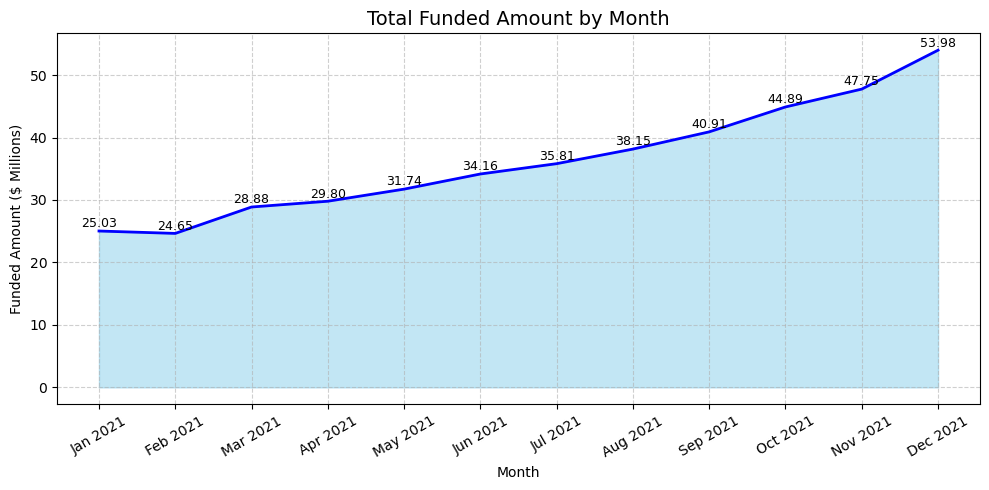

In [19]:
monthly_funded = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_millions'], color='skyblue',alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'], color='blue', linewidth=2)

for i, row in monthly_funded.iterrows():
    plt.text(i,row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']:.2f}",
            ha='center', va='bottom', fontsize=9, rotation= 0, color='black')
    
plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ($ Millions)')
plt.xticks(ticks=range(len(monthly_funded)), labels = monthly_funded['month_name'], rotation = 30 )
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Amount Received

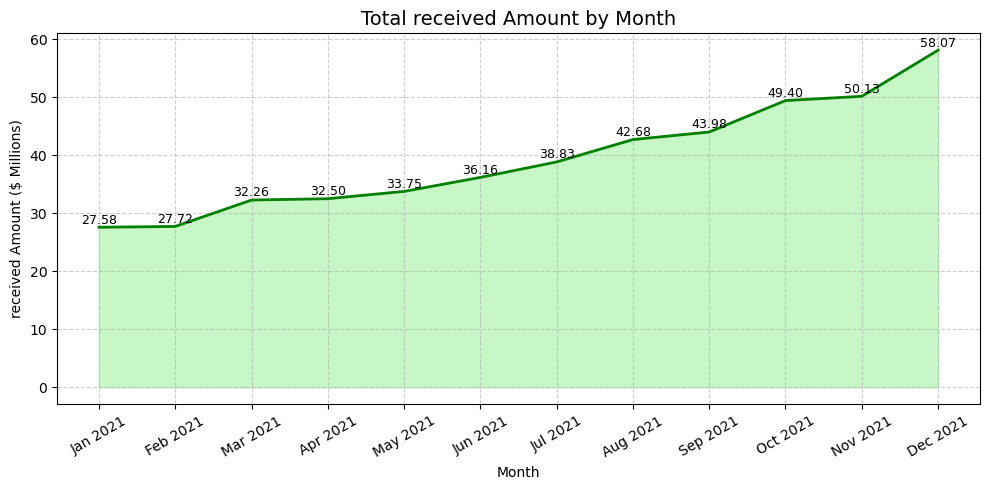

In [20]:
monthly_received = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_received['month_name'],monthly_received['received_amount_millions'], color='lightgreen',alpha=0.5)
plt.plot(monthly_received['month_name'],monthly_received['received_amount_millions'], color='Green', linewidth=2)

for i, row in monthly_received.iterrows():
    plt.text(i,row['received_amount_millions'] + 0.1, f"{row['received_amount_millions']:.2f}",
            ha='center', va='bottom', fontsize=9, rotation= 0, color='black')
    
plt.title('Total received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('received Amount ($ Millions)')
plt.xticks(ticks=range(len(monthly_received)), labels = monthly_received['month_name'], rotation = 30 )
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Loan Application

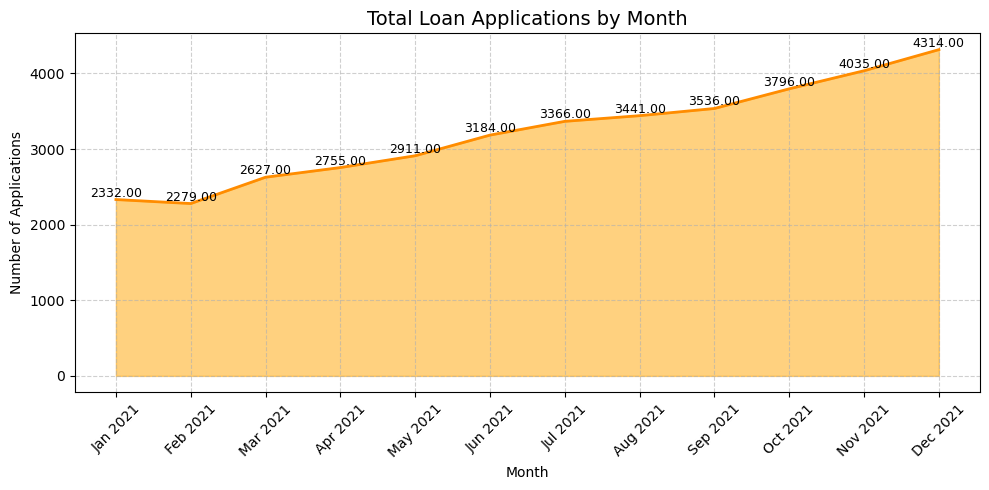

In [21]:
monthly_applications = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['id']
    .count()
    .reset_index(name='loan_application_count')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_applications['month_name'],monthly_applications['loan_application_count'], color='orange',alpha=0.5)
plt.plot(monthly_applications['month_name'],monthly_applications['loan_application_count'], color='darkorange', linewidth=2)

for i, row in monthly_applications.iterrows():
    plt.text(i,row['loan_application_count'] + 0.1, f"{row['loan_application_count']:.2f}",
            ha='center', va='bottom', fontsize=9, rotation= 0, color='black')
    
plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks=range(len(monthly_applications)), labels = monthly_applications['month_name'], rotation = 45 )
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

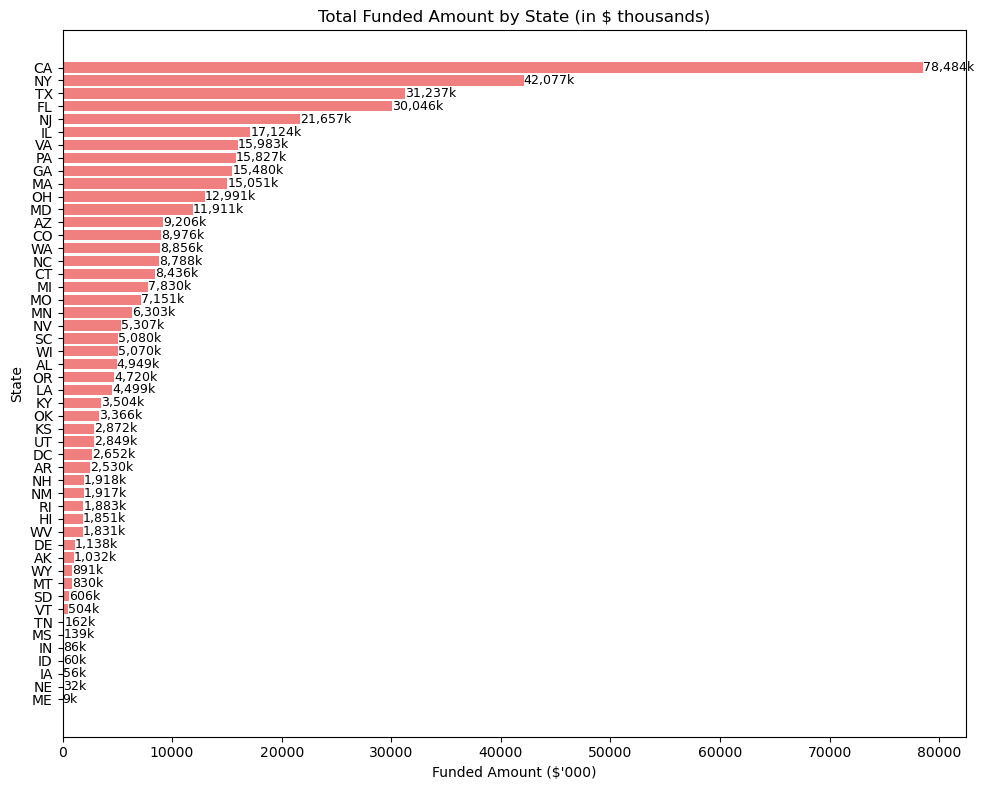

In [22]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding/1000

plt.figure(figsize=(10,8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values,color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10,bar.get_y() + bar.get_height() / 2,
            f'{width:,.0f}k', va='center',fontsize=9)

plt.title('Total Funded Amount by State (in $ thousands)')
plt.xlabel('Funded Amount ($\'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Loan Term Analysis by Total Funded Amount

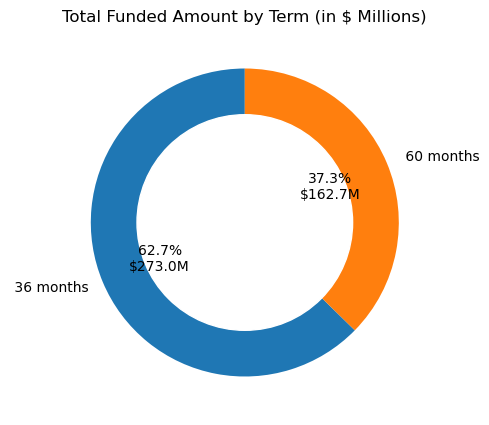

In [23]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize = (5,5))
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70, color='white'))
plt.title("Total Funded Amount by Term (in $ Millions)")
plt.show()


### Employee Length by Total Funded Amount

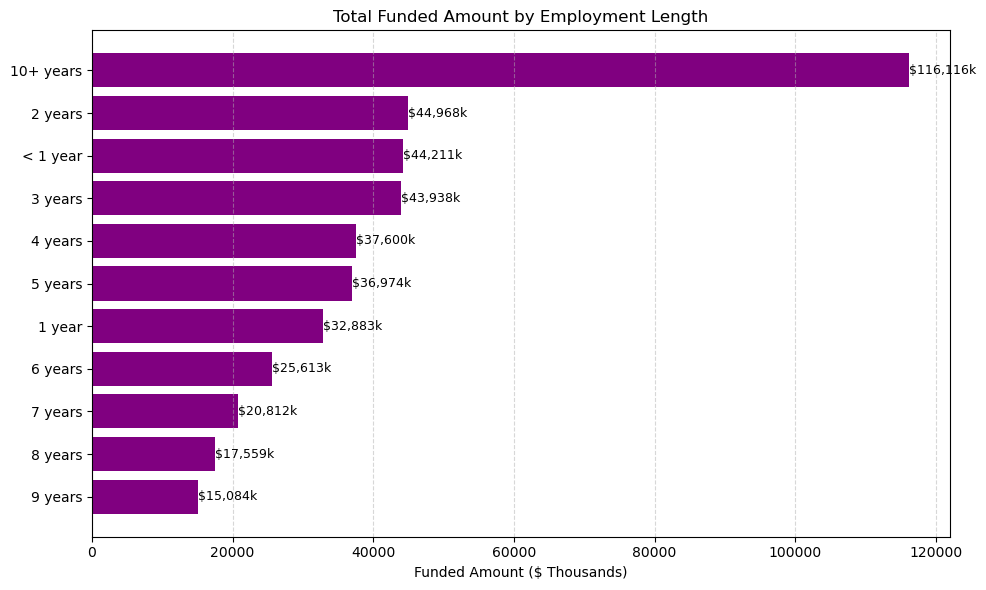

In [27]:
emp_funding_thousands = df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize=(10,6))
bars = plt.barh(emp_funding_thousands.index, emp_funding_thousands, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
            f"${width:,.0f}k", va='center', fontsize=9)

plt.title("Total Funded Amount by Employment Length")
plt.xlabel("Funded Amount ($ Thousands)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Purpose by Total Funded Amount

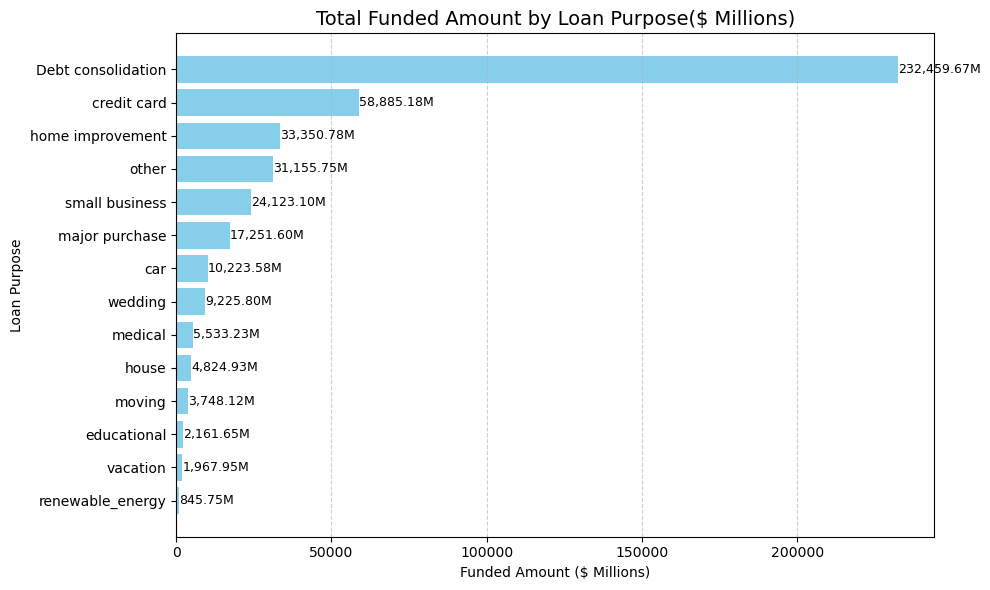

In [29]:
purpose_funding_millions = (df.groupby('purpose')['loan_amount'].sum().sort_values()/1000)

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_funding_millions.index, purpose_funding_millions.values, color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
            f'{width:,.2f}M', va='center', fontsize=9)

plt.title('Total Funded Amount by Loan Purpose($ Millions)',fontsize=14)
plt.xlabel('Funded Amount ($ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Home ownership by Total Funded Amount

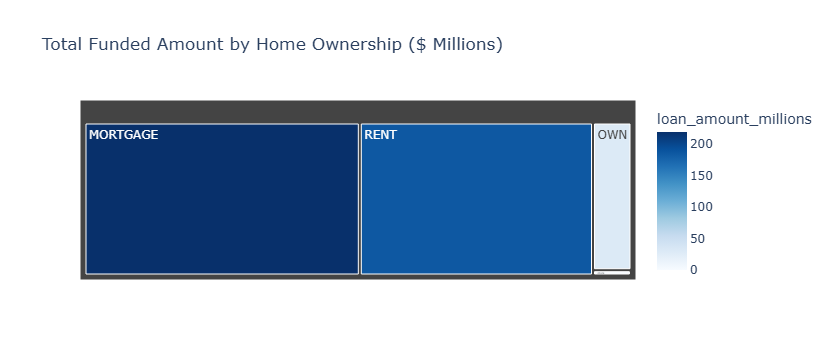

In [31]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount']/1_000_000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership ($ Millions)'
)

fig.show()

### Home ownership by Total Funded Amount